# Homework 12 — Results, Reporting & Delivery Design

**Chosen deliverable:** stakeholder PDF report, supported by this executed technical notebook  
**Audience:** portfolio risk analyst monitoring material AAPL exposure

This notebook turns the Stage 11 evaluation into a concise decision artifact. It regenerates all metrics and exports three self-contained charts to `reports/images/`.

In [1]:
# Reproducible setup and repository discovery
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'project' / 'data' / 'processed').exists():
    ROOT = ROOT.parent
if not (ROOT / 'project' / 'data' / 'processed').exists():
    raise FileNotFoundError('Run this notebook from inside the bootcamp_zizhe_zhou repository.')

STAGE11_DIR = ROOT / 'homework' / 'stage11'
if str(STAGE11_DIR) not in sys.path:
    sys.path.insert(0, str(STAGE11_DIR))
from src.evaluation import bootstrap_metric, gaussian_mean_ci, moving_block_bootstrap_metric, percentile_ci

STAGE_DIR = ROOT / 'homework' / 'stage12'
REPORT_DIR = STAGE_DIR / 'reports'
IMAGE_DIR = REPORT_DIR / 'images'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = 7
N_BOOT = 2_000
COLORS = {'navy': '#17324D', 'teal': '#1F7A8C', 'orange': '#F28E2B', 'red': '#C44536', 'gray': '#637381'}
sns.set_theme(style='whitegrid', context='notebook')
print('Report directory:', REPORT_DIR.relative_to(ROOT))

/Users/kevin/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/hx/wzbpnq8x7bzb6dg2sz74gg100000gn/T/matplotlib-kexe5ofc because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Report directory: homework/stage12/reports


## Executive summary

- **Use the model for daily attention ranking, not automated risk limits or hedging.**
- **Escalate human review when current 21-day volatility exceeds the training threshold.** Errors are materially higher in this regime.
- **Do not optimize only for average MAE.** Robust loss helps typical days but does not fix extreme-event underprediction.

In [2]:
feature_files = sorted((ROOT / 'project' / 'data' / 'processed').glob('aapl_model_features_*.parquet'))
if len(feature_files) != 1:
    raise RuntimeError(f'Expected one feature table, found: {feature_files}')

TARGET = 'target_next_day_absolute_return'
data = pd.read_parquet(feature_files[0]).sort_values('date').reset_index(drop=True)
feature_columns = [column for column in data.columns if column not in {'date', TARGET}]
split_index = int(len(data) * 0.75)
train, test = data.iloc[:split_index].copy(), data.iloc[split_index:].copy()
X_train, y_train = train[feature_columns], train[TARGET]
X_test, y_test = test[feature_columns], test[TARGET]
assert train['date'].max() < test['date'].min()
print('Training rows:', len(train), '| Test rows:', len(test))
print('Test period:', test['date'].min().date(), 'to', test['date'].max().date())

Training rows: 1235 | Test rows: 412
Test period: 2024-12-30 to 2026-08-21


## Recreate baseline, alternate scenario, and uncertainty

Ridge represents the squared-loss baseline. Huber is the alternate robust-loss scenario. All results use identical chronological test rows. Gaussian, IID bootstrap, and five-day block-bootstrap intervals quantify uncertainty in Ridge test MAE under increasingly time-aware assumptions.

In [3]:
models = {
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=100.0))]),
    'Huber': Pipeline([('scaler', StandardScaler()), ('model', HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=3000))]),
}
predictions = {}
metric_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    metric_rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, predictions[name]),
        'RMSE': np.sqrt(mean_squared_error(y_test, predictions[name])),
        'R2': r2_score(y_test, predictions[name]),
        'bias': np.mean(y_test.to_numpy() - predictions[name]),
    })
model_metrics = pd.DataFrame(metric_rows).set_index('model')
display(model_metrics.round(6))

ridge_errors = np.abs(y_test.to_numpy() - predictions['Ridge'])
gaussian_ci = gaussian_mean_ci(ridge_errors)
iid_distribution = bootstrap_metric(y_test.to_numpy(), predictions['Ridge'], mean_absolute_error, n_boot=N_BOOT, random_state=RANDOM_SEED)
block_distribution = moving_block_bootstrap_metric(y_test.to_numpy(), predictions['Ridge'], mean_absolute_error, block_size=5, n_boot=N_BOOT, random_state=RANDOM_SEED)
iid_ci, block_ci = percentile_ci(iid_distribution), percentile_ci(block_distribution)
display(pd.DataFrame({
    'lower_95': [gaussian_ci[0], iid_ci[0], block_ci[0]],
    'upper_95': [gaussian_ci[1], iid_ci[1], block_ci[1]],
}, index=['Gaussian', 'IID bootstrap', '5-day block bootstrap']).round(6))

,MAE,RMSE,R2,bias
model,,,,
Ridge,0.009291,0.013498,0.129482,-0.000999
Huber,0.008785,0.013663,0.108043,0.000934


,lower_95,upper_95
Gaussian,0.008344,0.010237
IID bootstrap,0.008405,0.010254
5-day block bootstrap,0.008291,0.010531


In [4]:
regime_threshold = train['rolling_vol_21d'].median()
evaluation = test[['date', TARGET, 'rolling_vol_21d']].copy()
evaluation['regime'] = np.where(evaluation['rolling_vol_21d'] > regime_threshold, 'Elevated', 'Calm')
for name in models:
    evaluation[name] = predictions[name]

subgroup_rows = []
for model_name in models:
    for regime, group in evaluation.groupby('regime'):
        subgroup_rows.append({
            'model': model_name, 'regime': regime, 'n': len(group),
            'MAE': mean_absolute_error(group[TARGET], group[model_name]),
            'RMSE': np.sqrt(mean_squared_error(group[TARGET], group[model_name])),
            'bias': np.mean(group[TARGET] - group[model_name]),
        })
subgroup_metrics = pd.DataFrame(subgroup_rows).set_index(['model', 'regime'])
display(subgroup_metrics.round(6))
print('Elevated-regime threshold:', round(regime_threshold, 6))

n       MAE      RMSE      bias
model regime                                     
Ridge Calm      213  0.008096  0.010802 -0.000111
      Elevated  199  0.010569  0.015885 -0.001950
Huber Calm      213  0.007659  0.010845  0.001465
      Elevated  199  0.009990  0.016143  0.000367

Elevated-regime threshold: 0.015997


## Chart 1 — Forecast behavior over time

**What it shows:** actual next-day absolute returns against the Ridge forecast in the held-out period.  
**Stakeholder insight:** the forecast responds to changing risk levels but compresses the largest spikes.  
**Limitation:** a model trained on historical patterns may not reproduce the size of a new shock.

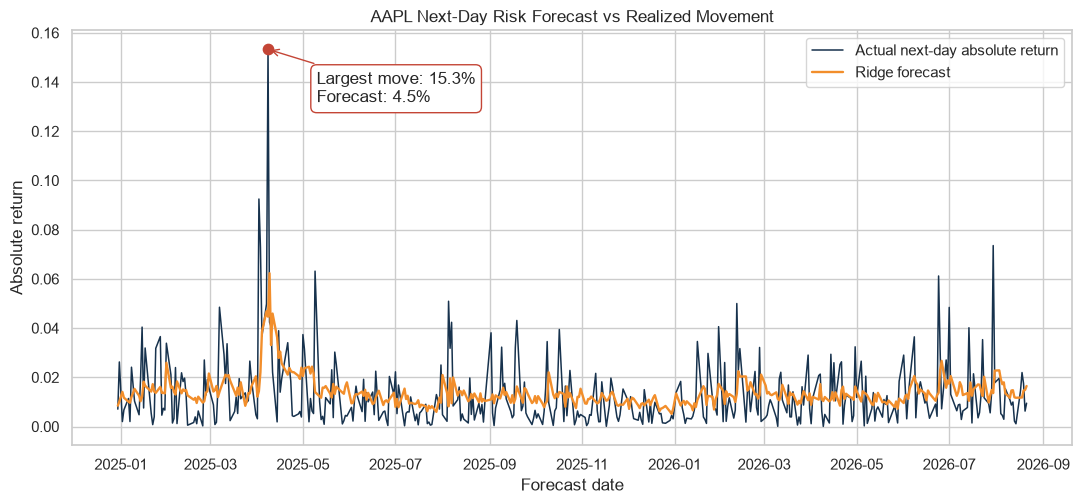

In [5]:
maximum_index = int(np.argmax(y_test.to_numpy()))
maximum_row = test.iloc[maximum_index]
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(test['date'], y_test, color=COLORS['navy'], linewidth=1.1, label='Actual next-day absolute return')
ax.plot(test['date'], predictions['Ridge'], color=COLORS['orange'], linewidth=1.7, label='Ridge forecast')
ax.scatter(test.iloc[maximum_index]['date'], y_test.iloc[maximum_index], color=COLORS['red'], s=55, zorder=4)
ax.annotate(
    f"Largest move: {y_test.iloc[maximum_index]*100:.1f}%\nForecast: {predictions['Ridge'][maximum_index]*100:.1f}%",
    xy=(test.iloc[maximum_index]['date'], y_test.iloc[maximum_index]), xytext=(35, -38),
    textcoords='offset points', arrowprops={'arrowstyle': '->', 'color': COLORS['red']},
    bbox={'boxstyle': 'round,pad=0.35', 'fc': 'white', 'ec': COLORS['red']},
)
ax.set(title='AAPL Next-Day Risk Forecast vs Realized Movement', xlabel='Forecast date', ylabel='Absolute return')
ax.legend(frameon=True)
fig.tight_layout()
forecast_chart = IMAGE_DIR / 'forecast_vs_actual.png'
fig.savefig(forecast_chart, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

## Chart 2 — Model-assumption sensitivity

**What it shows:** MAE and RMSE for squared-loss Ridge versus robust-loss Huber on identical dates.  
**Stakeholder insight:** Huber improves the typical miss but slightly worsens the metric that penalizes large misses.  
**Limitation:** neither metric alone represents the cost of failing to flag an extreme volatility day.

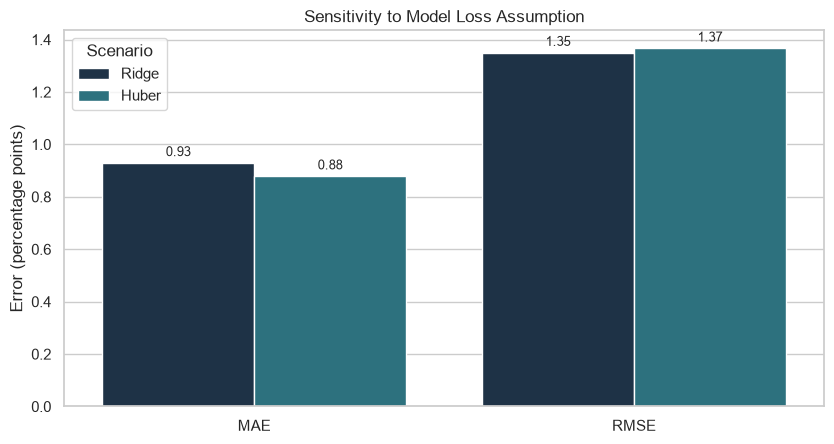

In [6]:
scenario_plot = model_metrics[['MAE', 'RMSE']].mul(100).reset_index().melt(id_vars='model', var_name='metric', value_name='percentage_points')
fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.barplot(data=scenario_plot, x='metric', y='percentage_points', hue='model', palette=[COLORS['navy'], COLORS['teal']], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
ax.set(title='Sensitivity to Model Loss Assumption', xlabel='', ylabel='Error (percentage points)')
ax.legend(title='Scenario')
fig.tight_layout()
scenario_chart = IMAGE_DIR / 'model_scenario_sensitivity.png'
fig.savefig(scenario_chart, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

## Chart 3 — Operating-regime risk

**What it shows:** model MAE split by a forecast-time volatility category.  
**Stakeholder insight:** elevated-volatility conditions are materially harder; this is where human escalation is most valuable.  
**Limitation:** the threshold is estimated from training history and may need recalibration after regime shifts.

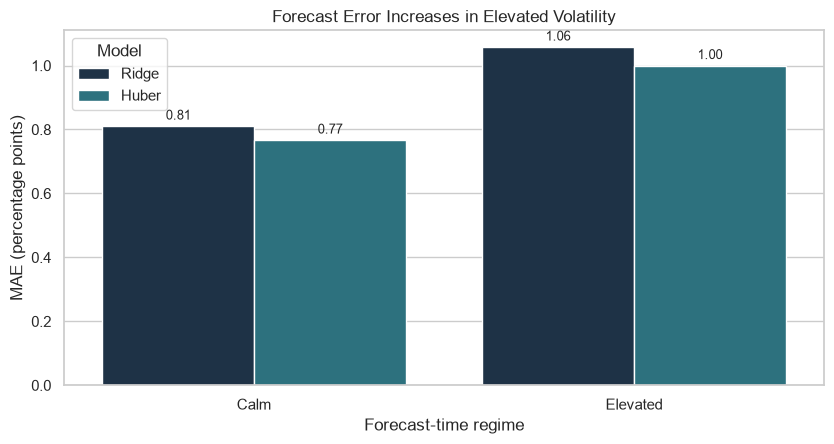

In [7]:
regime_plot = subgroup_metrics.reset_index()
regime_plot['MAE_pp'] = regime_plot['MAE'] * 100
fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.barplot(data=regime_plot, x='regime', y='MAE_pp', hue='model', order=['Calm', 'Elevated'], palette=[COLORS['navy'], COLORS['teal']], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
ax.set(title='Forecast Error Increases in Elevated Volatility', xlabel='Forecast-time regime', ylabel='MAE (percentage points)')
ax.legend(title='Model')
fig.tight_layout()
regime_chart = IMAGE_DIR / 'regime_risk_comparison.png'
fig.savefig(regime_chart, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

## Sensitivity summary and decision implications

The report translates the alternate assumptions into three operating choices: use robust loss only if typical-day MAE is the priority; use the wider block-bootstrap interval for planning; and trigger human review in elevated volatility. The model remains advisory and must not execute trades or set limits automatically.

In [8]:
ridge_mae = model_metrics.loc['Ridge', 'MAE']
huber_mae = model_metrics.loc['Huber', 'MAE']
ridge_rmse = model_metrics.loc['Ridge', 'RMSE']
huber_rmse = model_metrics.loc['Huber', 'RMSE']
calm_mae = subgroup_metrics.loc[('Ridge', 'Calm'), 'MAE']
elevated_mae = subgroup_metrics.loc[('Ridge', 'Elevated'), 'MAE']
sensitivity_table = pd.DataFrame([
    {'assumption_or_scenario': 'Huber robust loss', 'change_from_baseline': f"MAE {(huber_mae/ridge_mae-1):.1%}; RMSE {(huber_rmse/ridge_rmse-1):.1%}", 'decision_implication': 'Better typical day; no tail-risk cure'},
    {'assumption_or_scenario': 'Elevated volatility', 'change_from_baseline': f"Ridge MAE {(elevated_mae/calm_mae-1):.1%}", 'decision_implication': 'Escalate human review'},
    {'assumption_or_scenario': '5-day dependence', 'change_from_baseline': f"CI width {(block_ci[1]-block_ci[0])/(iid_ci[1]-iid_ci[0])-1:.1%} vs IID", 'decision_implication': 'Use wider block interval'},
])
display(sensitivity_table)
sensitivity_table.to_csv(REPORT_DIR / 'sensitivity_summary.csv', index=False)

summary = {
    'test_period': {'start': str(test['date'].min().date()), 'end': str(test['date'].max().date()), 'rows': len(test)},
    'models': {name: {key: float(model_metrics.loc[name, key]) for key in ['MAE', 'RMSE', 'R2', 'bias']} for name in models},
    'uncertainty': {'gaussian_95': list(map(float, gaussian_ci)), 'iid_bootstrap_95': list(map(float, iid_ci)), 'block_bootstrap_95': list(map(float, block_ci))},
    'regime_threshold': float(regime_threshold),
    'subgroups': {name: {regime.lower(): {key: float(subgroup_metrics.loc[(name, regime), key]) for key in ['MAE', 'RMSE', 'bias']} for regime in ['Calm', 'Elevated']} for name in models},
    'tail_check': {'forecast_date': str(maximum_row['date'].date()), 'actual': float(y_test.iloc[maximum_index]), 'predicted': float(predictions['Ridge'][maximum_index])},
}
(REPORT_DIR / 'summary_metrics.json').write_text(json.dumps(summary, indent=2))
print('Exported charts and report inputs:')
for path in sorted(REPORT_DIR.rglob('*')):
    if path.is_file():
        print('-', path.relative_to(STAGE_DIR))

,assumption_or_scenario,change_from_baseline,decision_implication
0,Huber robust loss,MAE -5.4%; RMSE 1.2%,Better typical day; no tail-risk cure
1,Elevated volatility,Ridge MAE 30.5%,Escalate human review
2,5-day dependence,CI width 21.1% vs IID,Use wider block interval


Exported charts and report inputs:
- reports/README.md
- reports/final_report.md
- reports/images/forecast_vs_actual.png
- reports/images/model_scenario_sensitivity.png
- reports/images/regime_risk_comparison.png
- reports/sensitivity_summary.csv
- reports/summary_metrics.json


## Assumptions and risks

- Historical AAPL relationships and vendor data remain representative enough for monitoring.
- The target is a next-day volatility proxy, not a portfolio P&L forecast or causal estimate.
- Bootstrap intervals describe average test MAE for a fixed model; they do not include refitting uncertainty or an unseen crisis.
- Correlated rolling features, corporate events, and changing market regimes can degrade calibration.
- Average metrics conceal tail misses. Decision use must include regime escalation and human review.